在这个工作是是将航班频次作为边的权重

## 加载数据

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv')


# 查看前几行数据，确保加载成功
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5999225 entries, 0 to 5999224
Data columns (total 21 columns):
 #   Column      Dtype  
---  ------      -----  
 0   flt_no      object 
 1   bd_type     object 
 2   cap         float64
 3   aircraft    object 
 4   legs        int64  
 5   leg_no      int64  
 6   duration    float64
 7   pax         int64  
 8   a           object 
 9   b           object 
 10  c           object 
 11  year        int64  
 12  month       int64  
 13  day         int64  
 14  weekday     int64  
 15  hour        int64  
 16  minute      int64  
 17  second      int64  
 18  from        object 
 19  to          object 
 20  unit_price  float64
dtypes: float64(3), int64(10), object(8)
memory usage: 961.2+ MB
None


## 生成加权图

In [2]:
# 创建一个新的数据框，用于存储航班频数
flight_counts = data.groupby(['from', 'to']).size().reset_index(name='flight_count')

# 打印查看
print(flight_counts.shape)
print(flight_counts.head())


(7908, 3)
           from            to  flight_count
0  +3eoTOkHfoU=  0Koyk9pJc0s=            50
1  +3eoTOkHfoU=  4j3sFPu6XuA=            46
2  +3eoTOkHfoU=  9obCP1myMDU=             8
3  +3eoTOkHfoU=  CnmNtb5MOJA=           111
4  +3eoTOkHfoU=  CzI09pVjQzQ=             8


In [3]:
import networkx as nx

# 创建一个空图
G = nx.Graph()

# 将城市作为节点，航班频数作为边的权重添加到图中
for index, row in flight_counts.iterrows():
    G.add_edge(row['from'], row['to'], weight=row['flight_count'])

# 输出图的基本信息
print("图的节点数:", G.number_of_nodes())
print("图的边数:", G.number_of_edges())

图的节点数: 252
图的边数: 4004


/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33322 (\N{CJK UNIFIED IDEOGRAPH-822A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29677 (\N{CJK UNIFIED IDEOGRAPH-73ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/

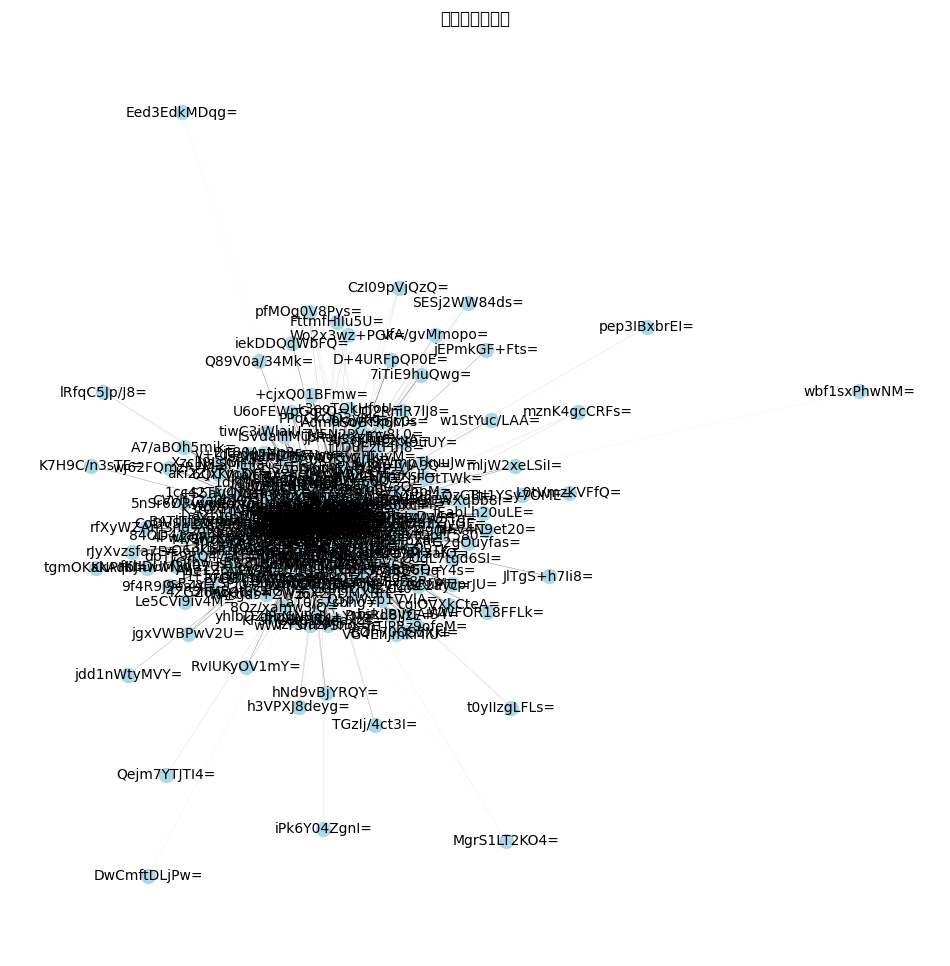

In [4]:
import matplotlib.pyplot as plt

# 设置图的布局
plt.figure(figsize=(12, 12))

# 绘制加权图，边的宽度表示航班频数
pos = nx.spring_layout(G, k=0.5)  # 使用 spring 布局来可视化图
edges = G.edges(data=True)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightblue')

# 绘制边，边的宽度表示航班频数（weight）
nx.draw_networkx_edges(G, pos, width=[d['weight'] / 1000 for u, v, d in edges], alpha=0.5)

# 绘制节点标签
nx.draw_networkx_labels(G, pos, font_size=10)

# 显示图形
plt.title("加权航班网络图")
plt.axis('off')
plt.show()

## 创建并训练 DeepWalk 模型

In [5]:
import numpy
print(numpy.__version__)

1.26.4


In [6]:
import networkx as nx
from node2vec import Node2Vec

1. 加载图并准备数据

In [7]:
node2vec = Node2Vec(G, 
                   dimensions=64, 
                   walk_length=3, 
                   num_walks=200, 
                   workers=4,
                   weight_key='weight')

model = node2vec.fit(window=3, 
                    min_count=1, 
                    batch_words=4)

Computing transition probabilities:   0%|          | 0/252 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 348.01it/s]


2. 获取节点的嵌入向量

In [8]:
# 获取城市嵌入表示
city_embeddings = {}
for city in G.nodes():
    city_embeddings[city] = model.wv[city]  # 从模型中提取城市嵌入

# 打印第一个城市的嵌入表示
print(city_embeddings[list(G.nodes())[0]])

[ 0.48277822 -0.3598762  -0.09247886  0.347991    0.44457027 -0.42878848
  0.06470772 -0.13692437 -0.20607825 -0.5748219   0.49013206 -0.30849063
 -0.45550957 -0.15054946  0.14689286  0.60953933 -0.7747353   0.12013382
  0.1946457   0.46170622 -0.09986523  0.14432563  0.8356903  -0.33161867
  0.37985837  0.26776767  0.3393118   0.01445785  0.27673906  0.13925533
  0.23170748  0.05754617 -0.17156659 -0.36158463  0.17326146  0.08966383
 -0.14437719  0.15259029 -0.04163317 -0.13912115  0.05770868  0.27356857
 -0.09050181 -0.01766762  0.72109693  0.06798552 -0.05460489 -0.36888695
  0.22459792  0.6011177  -0.15263754 -0.05693232  0.46852076  0.5557208
  0.29490095  0.14325961  0.03985297 -0.22460175 -0.08694233  0.04660746
 -0.21901359 -0.11590897  0.04031899 -0.00546157]


city_embeddings是一个字典

## 进行聚类

步骤 3：使用嵌入向量进行下游任务（例如聚类）

In [9]:
from sklearn.cluster import KMeans
import numpy as np

# 提取嵌入向量
embeddings = np.array([city_embeddings[city] for city in G.nodes()])

# 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)  # 设置簇的数量为3
kmeans.fit(embeddings)

# 查看每个城市的聚类标签
city_labels = dict(zip(G.nodes(), kmeans.labels_))

# 打印城市及其对应的聚类标签
for city, label in city_labels.items():
    print(f"城市: {city}, 聚类标签: {label}")


城市: +3eoTOkHfoU=, 聚类标签: 2
城市: 0Koyk9pJc0s=, 聚类标签: 2
城市: 4j3sFPu6XuA=, 聚类标签: 2
城市: 9obCP1myMDU=, 聚类标签: 1
城市: CnmNtb5MOJA=, 聚类标签: 1
城市: CzI09pVjQzQ=, 聚类标签: 2
城市: DInJHXgQayE=, 聚类标签: 2
城市: EIsXRbFUH34=, 聚类标签: 2
城市: MSFyivV4ETI=, 聚类标签: 2
城市: N4hmDZN/CJQ=, 聚类标签: 1
城市: UO2RniR7lJ8=, 聚类标签: 2
城市: XUXDuFGVfBM=, 聚类标签: 2
城市: ZCvDTbZuS8Q=, 聚类标签: 2
城市: gK3uAaRHrOs=, 聚类标签: 1
城市: jVYRvyHjuvM=, 聚类标签: 2
城市: +O1iBQtlFGU=, 聚类标签: 0
城市: /M8gHzjxpNU=, 聚类标签: 1
城市: 0J4jz5aCatU=, 聚类标签: 1
城市: AKQNtuL5r6Q=, 聚类标签: 1
城市: AlGb30xUGAU=, 聚类标签: 1
城市: C3VfOpfT580=, 聚类标签: 1
城市: Eg2bemFsI9I=, 聚类标签: 1
城市: FWD6O2fHsIU=, 聚类标签: 1
城市: KETr2NAmAHE=, 聚类标签: 1
城市: KFsTKxkC/6g=, 聚类标签: 1
城市: Qe7TEMbQt6o=, 聚类标签: 1
城市: QyEgIt0M8Sg=, 聚类标签: 1
城市: So/c8CkA/Xs=, 聚类标签: 1
城市: XuLAnICDnIM=, 聚类标签: 1
城市: a2cXIUGpIbw=, 聚类标签: 1
城市: g1hKMyP1V8I=, 聚类标签: 1
城市: iX2Pe2pxiqQ=, 聚类标签: 0
城市: lI1bSVMW3Tg=, 聚类标签: 0
城市: mljW2xeLSiI=, 聚类标签: 0
城市: ngSgjHYUqxE=, 聚类标签: 1
城市: tKjndGSl9NQ=, 聚类标签: 1
城市: vbo2dwBOeps=, 聚类标签: 1
城市: yypkiQCX5lk=, 聚类标签: 1
城市: +S5aV4Y0

### 保存聚类标签

In [10]:
# 首先导入 json 模块
import json
print(city_labels)

# 将字典中的所有值转换为 Python 的原生 int 类型
city_labels = {key: int(value) for key, value in city_labels.items()}

# 保存字典到 JSON 文件
with open('../../data-hh/my/encoder/city_labels_航班频率加权图标签.json', 'w') as file:
    json.dump(city_labels, file)

print("字典已保存为 city_labels.json")

{'+3eoTOkHfoU=': 2, '0Koyk9pJc0s=': 2, '4j3sFPu6XuA=': 2, '9obCP1myMDU=': 1, 'CnmNtb5MOJA=': 1, 'CzI09pVjQzQ=': 2, 'DInJHXgQayE=': 2, 'EIsXRbFUH34=': 2, 'MSFyivV4ETI=': 2, 'N4hmDZN/CJQ=': 1, 'UO2RniR7lJ8=': 2, 'XUXDuFGVfBM=': 2, 'ZCvDTbZuS8Q=': 2, 'gK3uAaRHrOs=': 1, 'jVYRvyHjuvM=': 2, '+O1iBQtlFGU=': 0, '/M8gHzjxpNU=': 1, '0J4jz5aCatU=': 1, 'AKQNtuL5r6Q=': 1, 'AlGb30xUGAU=': 1, 'C3VfOpfT580=': 1, 'Eg2bemFsI9I=': 1, 'FWD6O2fHsIU=': 1, 'KETr2NAmAHE=': 1, 'KFsTKxkC/6g=': 1, 'Qe7TEMbQt6o=': 1, 'QyEgIt0M8Sg=': 1, 'So/c8CkA/Xs=': 1, 'XuLAnICDnIM=': 1, 'a2cXIUGpIbw=': 1, 'g1hKMyP1V8I=': 1, 'iX2Pe2pxiqQ=': 0, 'lI1bSVMW3Tg=': 0, 'mljW2xeLSiI=': 0, 'ngSgjHYUqxE=': 1, 'tKjndGSl9NQ=': 1, 'vbo2dwBOeps=': 1, 'yypkiQCX5lk=': 1, '+S5aV4Y0s8w=': 1, 'Szk6NJM5C9Y=': 1, 'hwin1ipuzwk=': 1, 'nJFTk7JNmpw=': 1, 'wSF4qXvI044=': 1, 'xIqe+QQIQXQ=': 1, 'zwVGiYamVc0=': 1, '+cjxQ01BFmw=': 0, '/qxKZMQeBus=': 1, '07fT2dsZOJM=': 1, '1/9nd1jNCE0=': 1, '2WRfpdopfDw=': 1, '3nMB4t9SNGw=': 1, '4J2zqjPuTyI=': 1, '4Liydpz6+u

## 二维空间聚类效果展示

步骤 4：可视化嵌入

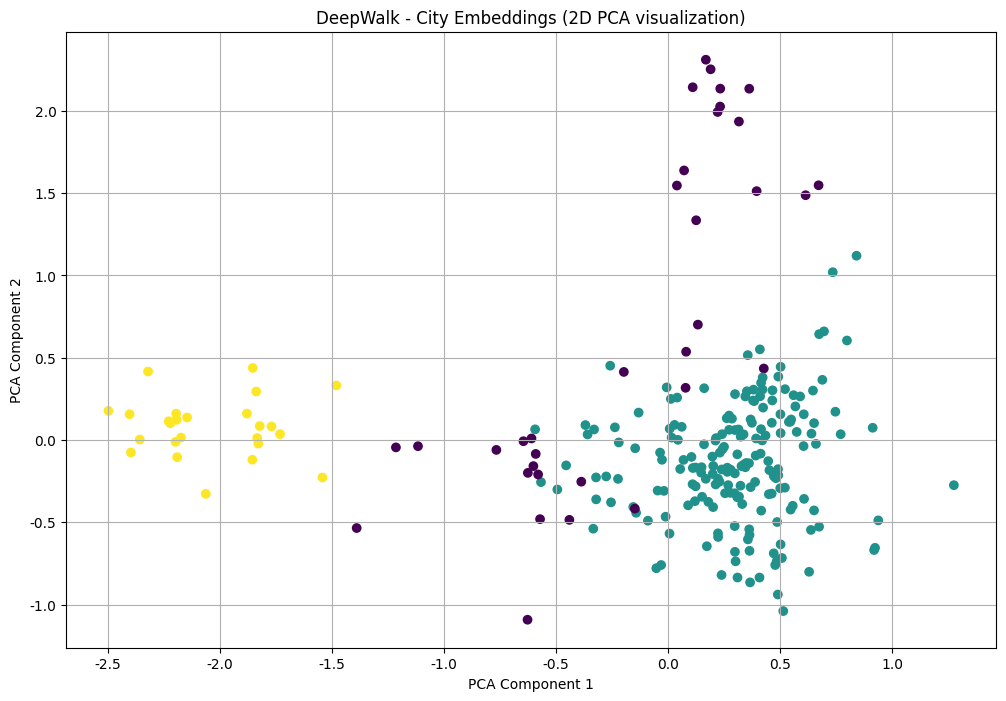

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 绘制散点图
plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans.labels_, cmap='viridis')

# 去掉为每个城市添加标签的部分
# for i, city in enumerate(G.nodes()):
#     plt.text(reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1, city, fontsize=9)

plt.title("DeepWalk - City Embeddings (2D PCA visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算城市之间的相似度
similarity_matrix = cosine_similarity(embeddings)

# 打印第一个城市和其他城市的相似度
for i, city in enumerate(G.nodes()):
    print(f"城市: {city}, 相似度: {similarity_matrix[0, i]}")

城市: +3eoTOkHfoU=, 相似度: 1.0000001192092896
城市: 0Koyk9pJc0s=, 相似度: 0.9451690316200256
城市: 4j3sFPu6XuA=, 相似度: 0.9693177342414856
城市: 9obCP1myMDU=, 相似度: 0.3840641677379608
城市: CnmNtb5MOJA=, 相似度: 0.28664276003837585
城市: CzI09pVjQzQ=, 相似度: 0.9790602326393127
城市: DInJHXgQayE=, 相似度: 0.8652781844139099
城市: EIsXRbFUH34=, 相似度: 0.97624671459198
城市: MSFyivV4ETI=, 相似度: 0.9406337738037109
城市: N4hmDZN/CJQ=, 相似度: 0.5808329582214355
城市: UO2RniR7lJ8=, 相似度: 0.9640313982963562
城市: XUXDuFGVfBM=, 相似度: 0.7350084185600281
城市: ZCvDTbZuS8Q=, 相似度: 0.9083315134048462
城市: gK3uAaRHrOs=, 相似度: 0.42995649576187134
城市: jVYRvyHjuvM=, 相似度: 0.9526933431625366
城市: +O1iBQtlFGU=, 相似度: 0.4943370819091797
城市: /M8gHzjxpNU=, 相似度: 0.1686992645263672
城市: 0J4jz5aCatU=, 相似度: 0.1095510944724083
城市: AKQNtuL5r6Q=, 相似度: 0.3030998110771179
城市: AlGb30xUGAU=, 相似度: 0.43761366605758667
城市: C3VfOpfT580=, 相似度: 0.5814235210418701
城市: Eg2bemFsI9I=, 相似度: 0.48971614241600037
城市: FWD6O2fHsIU=, 相似度: 0.26387038826942444
城市: KETr2NAmAHE=, 相似度: 0.220562

轮廓系数是评估聚类质量的常用指标，范围是 -1 到 1，值越大表示聚类效果越好。它同时考虑了簇内紧密度（每个点与所在簇中其他点的距离）和簇间分离度（每个点与最近簇的距离）。

值的意义：

值接近 +1：说明数据点与同簇内的点很接近，且与其他簇的点有很大区别，聚类效果好。

值接近 0：表示数据点可能位于两个簇的边界上，聚类效果一般。

值接近 -1：表示数据点可能被错误地归类到某个簇中，聚类效果差。

In [13]:
from sklearn.metrics import silhouette_score
score = silhouette_score(reduced_embeddings, kmeans.labels_)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.523409903049469


## 保存嵌入表示

In [14]:
import numpy as np
import json

# 获取城市列表
cities = list(city_embeddings.keys())

# 将降维后的嵌入表示转换为列表格式
reduced_embeddings_list = reduced_embeddings.tolist()

# 保存城市和其对应的嵌入（将 NumPy 数组转换为列表）
city_embedding_dict = {city: reduced_embeddings[i].tolist() for i, city in enumerate(cities)}

# 将 city_embedding_dict 保存为 JSON 文件
with open('../../data-hh/my/encoder/城市嵌入编码_航班频率加权图.json', 'w') as f:
    json.dump(city_embedding_dict, f)

print("城市嵌入表示已保存。")

城市嵌入表示已保存。


In [15]:
city_embedding_dict

{'+3eoTOkHfoU=': [-1.8391526937484741, 0.29507675766944885],
 '0Koyk9pJc0s=': [-2.147883415222168, 0.13705535233020782],
 '4j3sFPu6XuA=': [-1.8298976421356201, -0.021759580820798874],
 '9obCP1myMDU=': [0.32297399640083313, -0.27739566564559937],
 'CnmNtb5MOJA=': [0.4649088382720947, 0.2407354861497879],
 'CzI09pVjQzQ=': [-2.4047136306762695, 0.15701624751091003],
 'DInJHXgQayE=': [-2.3591227531433105, 0.0031644687987864017],
 'EIsXRbFUH34=': [-2.4991343021392822, 0.17730413377285004],
 'MSFyivV4ETI=': [-2.192129135131836, -0.10405419766902924],
 'N4hmDZN/CJQ=': [-0.3694944679737091, 0.09095978736877441],
 'UO2RniR7lJ8=': [-2.229687452316284, 0.11455941200256348],
 'XUXDuFGVfBM=': [-1.5436981916427612, -0.22770234942436218],
 'ZCvDTbZuS8Q=': [-2.0642027854919434, -0.32717394828796387],
 'gK3uAaRHrOs=': [-0.3342632055282593, -0.5387135148048401],
 'jVYRvyHjuvM=': [-1.7708462476730347, 0.0824417918920517],
 '+O1iBQtlFGU=': [-1.116939663887024, -0.03732094168663025],
 '/M8gHzjxpNU=': [0.46